## 환경 설정

In [26]:
import os
import datetime
import uuid
from dotenv import load_dotenv
from modules import logging
from typing_extensions import Annotated, Literal, Sequence, TypedDict, Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI
from IPython.display import Image, display
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.tools.retriever import create_retriever_tool
from modules.prompt import retriever_prompt
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import tools_condition
from modules.messages import _display_message_tree

In [2]:
# LangSmith Logging
logging.langsmith("Model_RAG")
# API 키 정보 로드
load_dotenv()

LangSmith 추적을 시작합니다.
[프로젝트명]
Model_RAG


True

## 파일 로드

In [3]:
ollama_embeddings = OllamaEmbeddings(
    model="nomic-embed-text"
)

loaded_db = FAISS.load_local(
    folder_path="faiss_db",
    index_name="meritz_index",
    embeddings=ollama_embeddings,
    allow_dangerous_deserialization=True,
)

C:\Users\vkxql\AppData\Local\Temp\ipykernel_8880\4185708034.py:1: LangChainDeprecationWarning: The class `OllamaEmbeddings` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaEmbeddings``.
  ollama_embeddings = OllamaEmbeddings(


## retriever / llm

In [4]:
retriever = loaded_db.as_retriever()

In [5]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [22]:
# retriever Tool
retriever_tool = create_retriever_tool(
    retriever,
    "retrieve_vector_database",
    "Search and return information about vector database on LLMs.",
)

tools = [retriever_tool]

In [7]:
class State(TypedDict):
    # 메시지 관리
    messages: Annotated[Sequence[BaseMessage], add_messages]
    # 세션 ID
    session_id: str
    # 기타 메타데이터 (사용자 정보, 소스 등)
    metadata: dict

In [8]:
# 새로운 세션 ID 생성
session_id = str(uuid.uuid4())

In [9]:
# MemorySaver 인스턴스 생성
memory = MemorySaver()

In [10]:
# 답변 분류
#


def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check."""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatOpenAI(temperature=0, model="gpt-4o-mini", streaming=True)

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # Prompt
    prompt = PromptTemplate(
        template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
        Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
        input_variables=["context", "question"],
    )
    
    
    # Chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---확인: 관련 된 문서 입니다.---")
        return "generate"

    if score == "no":
        print("---확인: 관련이 없는 문서 입니다.---")
        print(score)
        return "rewrite"

## Nodes

In [11]:
# Agent 노드

def agent(state):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatOpenAI(temperature=0, streaming=True, model="gpt-4o-mini")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [12]:
# Rewrite 노드

def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatOpenAI(temperature=0, model="gpt-4o-mini", streaming=True)
    response = model.invoke(msg)
    return {"messages": [response]}

In [13]:
# 답변 생성 노드

def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated state with re-phrased question
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0, streaming=True)

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

## Graph

In [15]:
# 초기화
workflow = StateGraph(State)

In [16]:
# Define the nodes we will cycle between
workflow.add_node("agent", agent)  # agent
retrieve = ToolNode([retriever_tool])
workflow.add_node("retrieve", retrieve)  # retrieval
workflow.add_node("rewrite", rewrite)  # Re-writing the question
workflow.add_node(
    "generate", generate
)  # Generating a response after we know the documents are relevant
# Call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

In [17]:
graph = workflow.compile(checkpointer=memory)

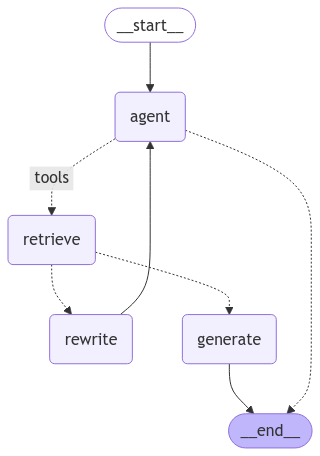

In [18]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [19]:
import pprint

In [ ]:
inputs = {
    "messages": [
        ("user", "자동차 보험에 대해 알려줘."),
    ]
}
for output in graph.stream(inputs):
    for key, value in output.items():
        pprint.pprint(f"Output from node '{key}':")
        pprint.pprint("---")
        pprint.pprint(value, indent=2, width=80, depth=None)
    pprint.pprint("\n---\n")

In [24]:
import pprint

# 입력 데이터 정의
inputs = {
    "messages": [
        ("user", "보헙비 산출 방식에 대해 알려줘."),
    ]
}

# Configurable 설정 (필요한 경우)
config = {"configurable": {"thread_id": "user_123"}}

# 그래프 스트림 실행
for output in graph.stream(inputs, config=config):
    # 각 노드의 출력 처리
    for key, value in output.items():
        print(f"\n{'-'*10} Output from node '{key}' {'-'*10}\n")
        
        # 메시지가 포함된 경우만 출력
        if "messages" in value:
            for message in value["messages"]:
                if hasattr(message, "content") and message.content:
                    print(f"**Message Content**:\n{message.content}\n")
        else:
            pprint.pprint(value, indent=2, width=80, depth=None)
        
        print("\n" + "-"*30 + "\n")


---CALL AGENT---

---------- Output from node 'agent' ----------

**Message Content**:
보험비(보험료) 산출 방식은 여러 요인에 따라 달라지며, 각 보험사마다 조금씩 다를 수 있습니다. 일반적으로 자동차 보험료를 산출하는 주요 요소는 다음과 같습니다.

1. **운전자의 개인 정보**:
   - **나이**: 젊은 운전자는 사고 위험이 높다고 판단되어 보험료가 더 비쌀 수 있습니다.
   - **성별**: 통계적으로 남성이 여성보다 사고를 더 많이 내는 경향이 있어 성별에 따라 보험료가 달라질 수 있습니다.
   - **운전 경력**: 운전 경력이 길수록 사고 위험이 낮다고 평가되어 보험료가 낮아질 수 있습니다.

2. **차량 정보**:
   - **차량의 종류**: 고급차나 스포츠카는 사고 시 수리 비용이 높아 보험료가 비쌀 수 있습니다.
   - **차량의 연식**: 신차일수록 보험료가 높을 수 있으며, 오래된 차량은 부품 수급 문제로 보험료가 낮아질 수 있습니다.
   - **차량의 안전성**: 안전 장치가 많이 장착된 차량은 사고 시 피해를 줄일 수 있어 보험료가 낮아질 수 있습니다.

3. **사고 이력**:
   - 과거 사고 이력이 있는 경우, 사고 위험이 높다고 판단되어 보험료가 인상될 수 있습니다.

4. **주행 거리**:
   - 연간 주행 거리가 많을수록 사고 위험이 높아져 보험료가 증가할 수 있습니다.

5. **거주 지역**:
   - 사고 발생률이 높은 지역에 거주할 경우 보험료가 높아질 수 있습니다.

6. **보험 가입 내역**:
   - 기존에 가입한 보험의 종류와 보장 범위에 따라 보험료가 달라질 수 있습니다.

7. **할인 혜택**:
   - 여러 보험사에서 제공하는 할인 혜택(예: 무사고 할인, 다차량 할인 등)을 적용받을 수 있습니다.

보험사는 이러한 요소들을 종합적으로 고려하여 보험료를 산출하며, 각 보험사마다 산출 방식이 다를 수 있으므로 여러 

In [32]:
_display_message_tree(output)

[agent]:
    [messages]:
        messages[0]:
            messages[0]: content='보험비(보험료) 산출 방식은 여러 요인에 따라 달라지며, 각 보험사마다 조금씩 다를 수 있습니다. 일반적으로 자동차 보험료를 산출하는 주요 요소는 다음과 같습니다.\n\n1. **운전자의 개인 정보**:\n   - **나이**: 젊은 운전자는 사고 위험이 높다고 판단되어 보험료가 더 비쌀 수 있습니다.\n   - **성별**: 통계적으로 남성이 여성보다 사고를 더 많이 내는 경향이 있어 성별에 따라 보험료가 달라질 수 있습니다.\n   - **운전 경력**: 운전 경력이 길수록 사고 위험이 낮다고 평가되어 보험료가 낮아질 수 있습니다.\n\n2. **차량 정보**:\n   - **차량의 종류**: 고급차나 스포츠카는 사고 시 수리 비용이 높아 보험료가 비쌀 수 있습니다.\n   - **차량의 연식**: 신차일수록 보험료가 높을 수 있으며, 오래된 차량은 부품 수급 문제로 보험료가 낮아질 수 있습니다.\n   - **차량의 안전성**: 안전 장치가 많이 장착된 차량은 사고 시 피해를 줄일 수 있어 보험료가 낮아질 수 있습니다.\n\n3. **사고 이력**:\n   - 과거 사고 이력이 있는 경우, 사고 위험이 높다고 판단되어 보험료가 인상될 수 있습니다.\n\n4. **주행 거리**:\n   - 연간 주행 거리가 많을수록 사고 위험이 높아져 보험료가 증가할 수 있습니다.\n\n5. **거주 지역**:\n   - 사고 발생률이 높은 지역에 거주할 경우 보험료가 높아질 수 있습니다.\n\n6. **보험 가입 내역**:\n   - 기존에 가입한 보험의 종류와 보장 범위에 따라 보험료가 달라질 수 있습니다.\n\n7. **할인 혜택**:\n   - 여러 보험사에서 제공하는 할인 혜택(예: 무사고 할인, 다차량 할인 등)을 적용받을 수 있습니다.\n\n보험사는 이러한 요소들을 종합적으로 고려하여 보험료를 산출하며, 각 보험사마다 